# A. Importation of libraries and Configs

In [ ]:
# Standard libraries
import pandas as pd

In [ ]:
import os
from pathlib import Path

# Run once at the top — sets cwd to Thesis/
os.chdir(Path().resolve().parents[1])  # eda → notebooks → Thesis

In [ ]:
from src.utils.data_loaders.read_settings_json import read_settings_json

args = read_settings_json()
args

{'Config': {'debug_mode': 'False', 'TEMP_CACHE': 'data/temp_cache'},
 'TrainingInput': {'CHART_OF_ACCOUNTS': 'data/training_input/chart_of_accounts.xlsx',
  'ENROLLEES': 'data/training_input/enrollees_pseudonymized.xlsx',
  'REVENUES': 'data/training_input/revenues_pseudonymized.xlsx'},
 'Training': {'MODEL_PARAMETERS': 'src/modules/machine_learning/parameters.json',
  'RESULTS_ROOT': 'data/training_results',
  'DEPLOYED_MODELS': 'data/training_results/deployed_models',
  'observation_end': '2026/04/24',
  'target_feature': 'dtp_bracket',
  'test_size': '0.30'}}

# B. Loading of datasets

## 1. Revenues

In [ ]:
df_revenues = pd.read_excel(args['TrainingInput']['REVENUES'], engine='calamine')

In [ ]:
df_revenues

,entry_number,entry_date,due_date,school_year,student_id_pseudonimized,category_name,discount_refund_applied_to,amount_due,amount_paid,account_name,receivables
0,0,2025-10-13,2025-10-13,2014,9XBPS6GQ,Form 137,NaN,150.0,150.0,G-Cash,0.0
1,1,2016-01-01,2016-01-01,2016,QCNXOF71,Back Account,NaN,3524.0,0.0,Not Applicable,3524.0
2,2,2016-01-01,2016-01-01,2016,UFN5RBCA,Back Account,NaN,9831.0,0.0,Not Applicable,9831.0
3,3,2016-01-01,2016-01-01,2016,CATF26JR,Back Account,NaN,9240.0,0.0,Not Applicable,9240.0
4,4,2016-01-01,2016-01-01,2016,TE11Z2LJ,Back Account,NaN,5886.0,0.0,Not Applicable,5886.0
...,...,...,...,...,...,...,...,...,...,...,...
53437,54692,2026-04-22,2026-07-11,2026,K13NY2L3,G06-A-UE,NaN,31000.0,31000.0,Cash,0.0
53438,54693,2026-04-22,2026-07-11,2026,K13NY2L3,Discount - 2nd Sibling,G06-OF-Full,-700.0,0.0,Not Applicable,-700.0
53439,54694,2026-04-22,2026-07-11,2026,K13NY2L3,G06-OF-Full,NaN,17900.0,0.0,Not Applicable,17900.0
53440,54695,2026-04-24,2026-07-11,2026,XKJ70D79,Kn2-A-UE,NaN,26400.0,26400.0,Bank,0.0


## 2. Enrollees

In [ ]:
df_enrollees = pd.read_excel(args['TrainingInput']['ENROLLEES'], engine='calamine')

In [ ]:
df_enrollees

,school_year,student_id_pseudonimized,plan_type,grade_level,enrollment_date,education_level,has_refunded
0,2018,08GNGU9D,Plan - D,G03,2018-06-07,Elementary,No Refund
1,2018,0JWX77BI,Plan - B,SpE,2018-06-07,Special Education,No Refund
2,2018,0LZJ7928,Plan - A,G01,2018-05-18,Elementary,No Refund
3,2018,15RI5SWE,Plan - B,G03,2018-06-06,Elementary,No Refund
4,2018,1IGM0VHQ,Plan - A,G01,2018-05-04,Elementary,No Refund
...,...,...,...,...,...,...,...
2780,2026,Z3FMQ7JI,Plan - A,G05,2026-01-09,Elementary,No Refund
2781,2026,ZDC3I53X,Plan - B,G10,2026-03-30,Junior High,No Refund
2782,2026,ZHRMZVJR,Plan - C,G06,2026-03-16,Elementary,No Refund
2783,2026,ZQB34VX6,Plan - A,SpE,2026-01-20,Special Education,No Refund


## 3. Credit Sales

In [ ]:
from src.modules.feature_engineering.credit_sales_machine_learning import CreditSalesProcessor

cs = CreditSalesProcessor(df_revenues, df_enrollees, args)
df_credit_sales = cs.show_data()

Single due date records:   10580
Multiple due date records: 289


In [ ]:
df_credit_sales

,school_year,student_id_pseudonimized,category_name,gross_receivables,amount_discounted,adjustments,credit_sale_amount,due_date,date_fully_paid,days_elapsed_until_fully_paid,...,due_month,due_quarter,opening_balance_flag,payment_ratio,early_payer_flag,on_time_streak,prev_bracket,dtp_rolling_std,dtp_max,plan_type_risk_score
2257,2022,02PNVPI5,Kn2-C-1st,2800.0,0.0,0.0,2800.0,2022-09-09,2022-09-06,-3,...,9,3,0,1.034215,NaN,0,NaN,<NA>,<NA>,0
2412,2022,02PNVPI5,Kn2-C-2nd,2800.0,0.0,0.0,2800.0,2022-11-05,NaT,1267,...,11,4,1,0.943797,1.0,1,0.0,<NA>,-3,0
2774,2022,02PNVPI5,Kn2-OF-2nd,2267.0,0.0,0.0,2267.0,2022-12-05,NaT,1237,...,12,4,1,0.881408,NaN,0,NaN,<NA>,-3,0
2971,2022,02PNVPI5,Events - Foundation Day,490.0,0.0,0.0,490.0,2022-12-16,NaT,1226,...,12,4,1,0.805478,NaN,0,NaN,<NA>,-3,0
2972,2022,02PNVPI5,Kn2 - Moving Up - Male,2600.0,0.0,0.0,2600.0,2022-12-16,NaT,1226,...,12,4,1,0.805478,NaN,0,NaN,<NA>,-3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9792,2025,ZXPL0CI9,G06-C-4th,5800.0,0.0,0.0,5800.0,2026-02-06,2026-02-09,3,...,2,1,1,0.972245,0.0,0,2.0,10.456258,34,0
9869,2025,ZXPL0CI9,Graduation - Other Services,1500.0,0.0,0.0,1500.0,2026-02-18,2026-03-23,33,...,2,1,1,0.992873,0.0,0,1.0,14.614491,34,0
9942,2025,ZXPL0CI9,Events - Foundation Day,400.0,0.0,0.0,400.0,2026-03-05,2026-03-11,6,...,3,1,1,0.990990,0.0,0,2.0,15.340578,34,0
9967,2025,ZXPL0CI9,G06-OF-3rd,5800.0,0.0,0.0,5800.0,2026-03-06,2026-03-11,5,...,3,1,1,0.964462,0.0,0,1.0,16.792856,34,0


# C. Exploratory Data Analysis

### c. Linear Discriminant Analysis

In [ ]:
df_credit_sales.columns

Index(['school_year', 'student_id_pseudonimized', 'category_name',
       'gross_receivables', 'amount_discounted', 'adjustments',
       'credit_sale_amount', 'due_date', 'date_fully_paid',
       'days_elapsed_until_fully_paid', 'dtp_1', 'dtp_2', 'dtp_3', 'dtp_4',
       'dtp_avg', 'dtp_wavg', 'due_date_prev_1', 'due_date_prev_2',
       'dtp_2_trend', 'dtp_3_trend', 'last_payment_date',
       'days_since_last_payment', 'amount_due_cumsum', 'amount_paid_cumsum',
       'opening_balance', 'plan_type_Plan - A', 'plan_type_Plan - B',
       'plan_type_Plan - C', 'plan_type_Plan - D', 'plan_type_Plan - E',
       'plan_type_nan', 'dtp_bracket', 'censor', 'due_month', 'due_quarter',
       'opening_balance_flag', 'payment_ratio', 'early_payer_flag',
       'on_time_streak', 'prev_bracket', 'dtp_rolling_std', 'dtp_max',
       'plan_type_risk_score'],
      dtype='object')


  LDA — Explained separation variance
  LD1: ██████████████████████████████████        85.8%
  LD2: █████                                     13.7%
  LD3:                                           0.4%

           feature   before    after  improvement_%
   opening_balance 0.371146 1.300404     250.375003
          dtp_wavg 0.288492 0.288492       0.000000
           dtp_avg 0.282797 0.282797       0.000000
     payment_ratio 0.238256 0.238256       0.000000
             dtp_1 0.209660 0.209660       0.000000
             dtp_2 0.199653 0.199653       0.000000
             dtp_3 0.171799 0.171799       0.000000
             dtp_4 0.151691 0.151691       0.000000
amount_paid_cumsum 0.036984 0.045659      23.455141
credit_sale_amount 0.016502 0.023609      43.068388
 amount_due_cumsum 0.016431 0.016671       1.461036

Saved → lda_all_brackets.png


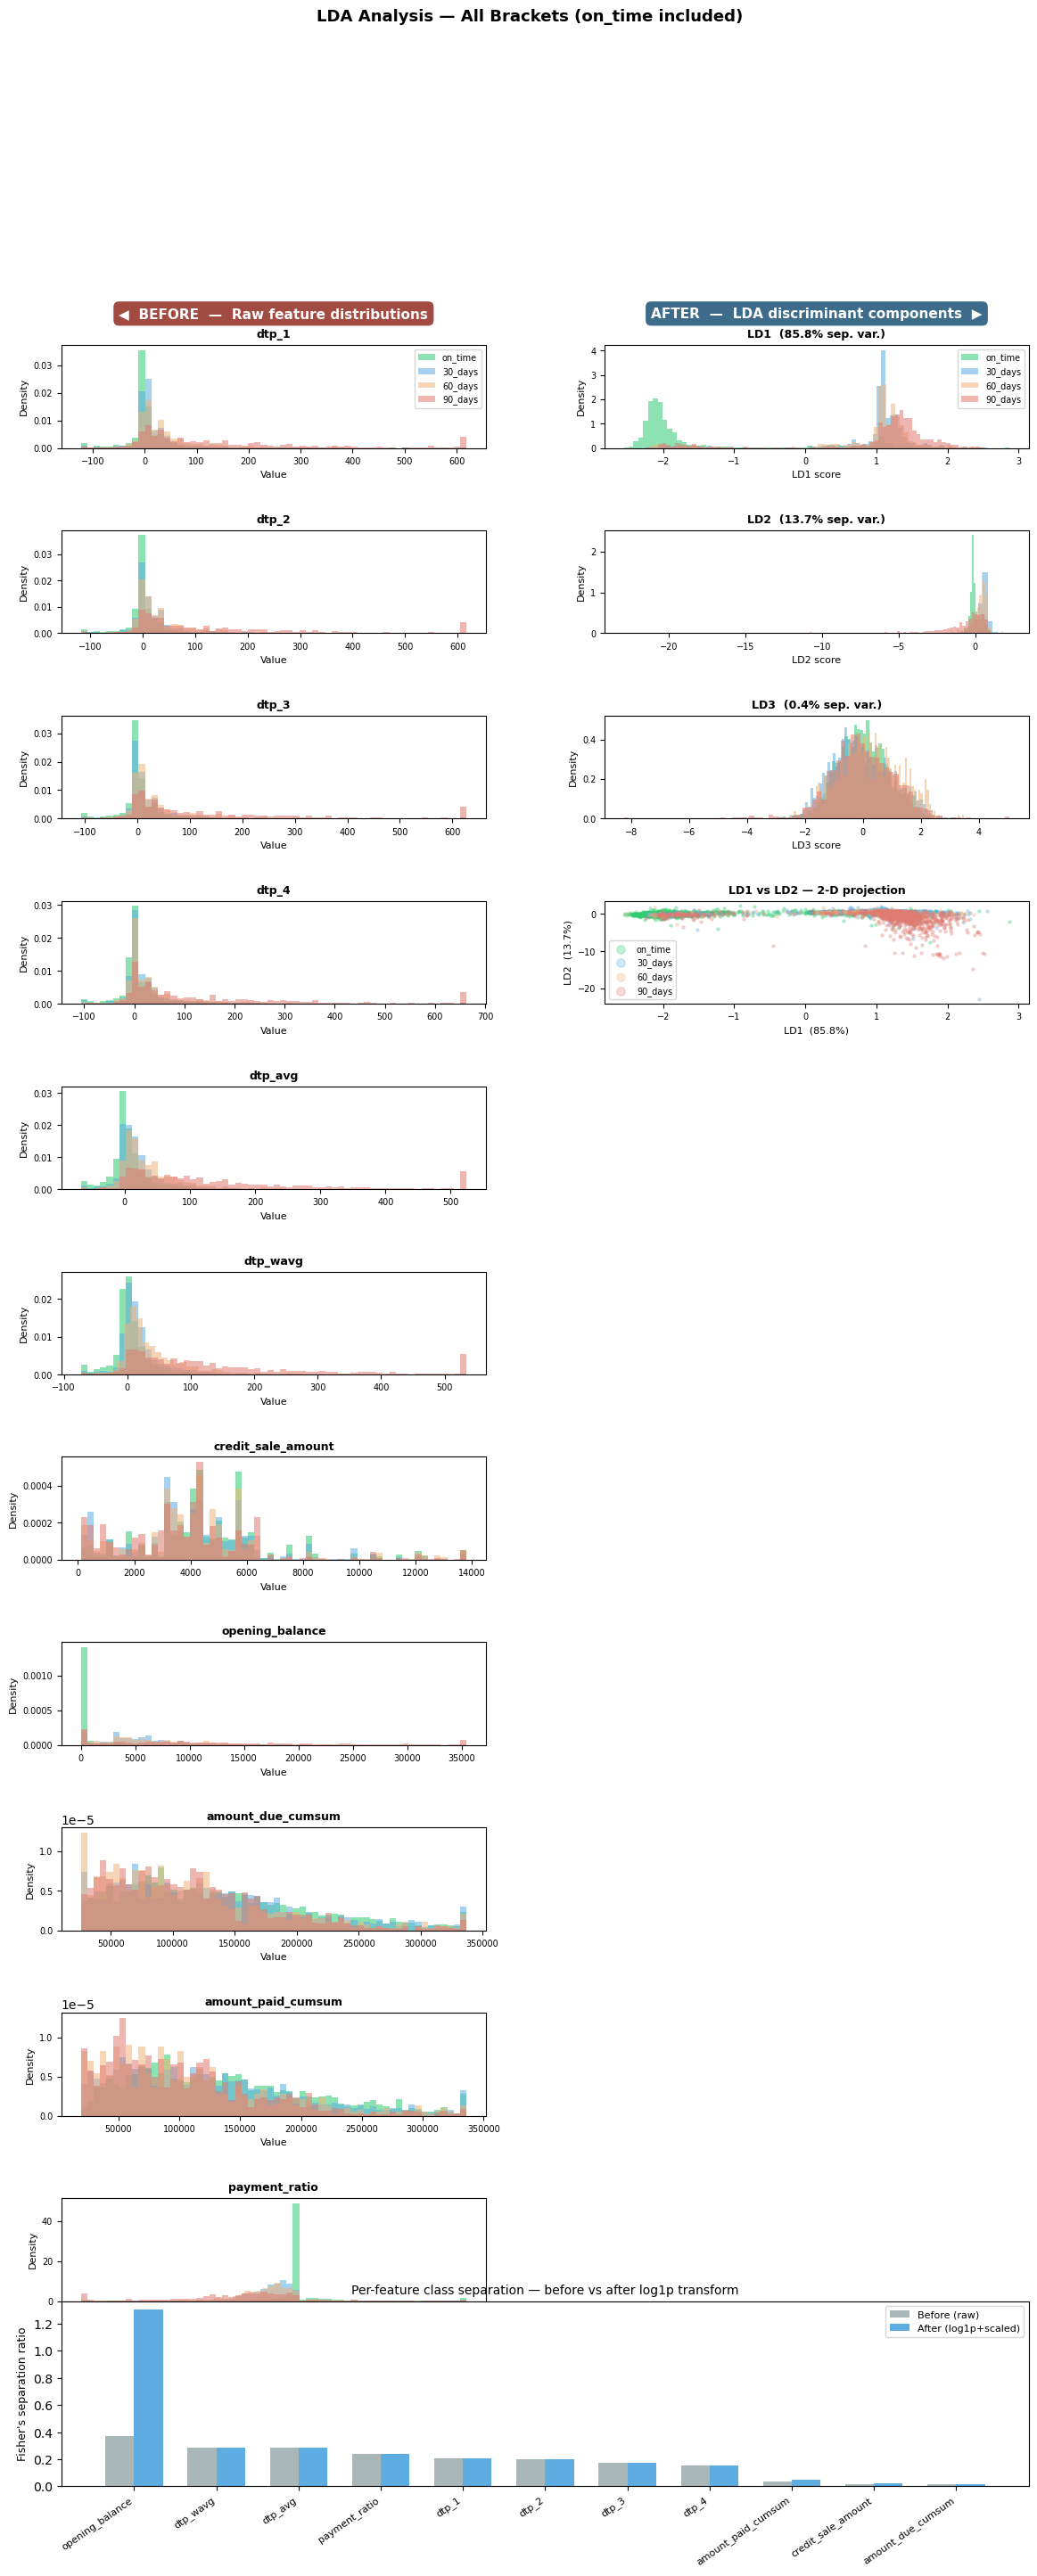

In [ ]:
from src.modules.exploratory_data_analysis.linear_discriminant_analysis import LDAAnalysis

lda_all = LDAAnalysis(
    df_credit_sales,
    bracket_order = ['on_time', '30_days', '60_days', '90_days'],
    output_path   = 'data/eda_results/lda_all_brackets.png',
    title         = 'LDA Analysis — All Brackets (on_time included)',
)
pipe, X_lda, evr, sep_df = lda_all.run()

### d. LDA (Delinquent)


  LDA — Explained separation variance
  LD1: ██████████████████████████████████████    96.1%
  LD2: █                                         3.9%

           feature   before    after  improvement_%
          dtp_wavg 0.223186 0.223186       0.000000
           dtp_avg 0.220301 0.220301       0.000000
             dtp_2 0.165980 0.165980       0.000000
             dtp_1 0.161324 0.161324       0.000000
             dtp_3 0.135269 0.135269       0.000000
   opening_balance 0.129616 0.002201     -98.302236
             dtp_4 0.128935 0.128935       0.000000
     payment_ratio 0.076754 0.076754       0.000000
amount_paid_cumsum 0.022771 0.022639      -0.581303
 amount_due_cumsum 0.013585 0.011401     -16.075207
credit_sale_amount 0.001915 0.003666      91.436622

Saved → lda_delinquent.png


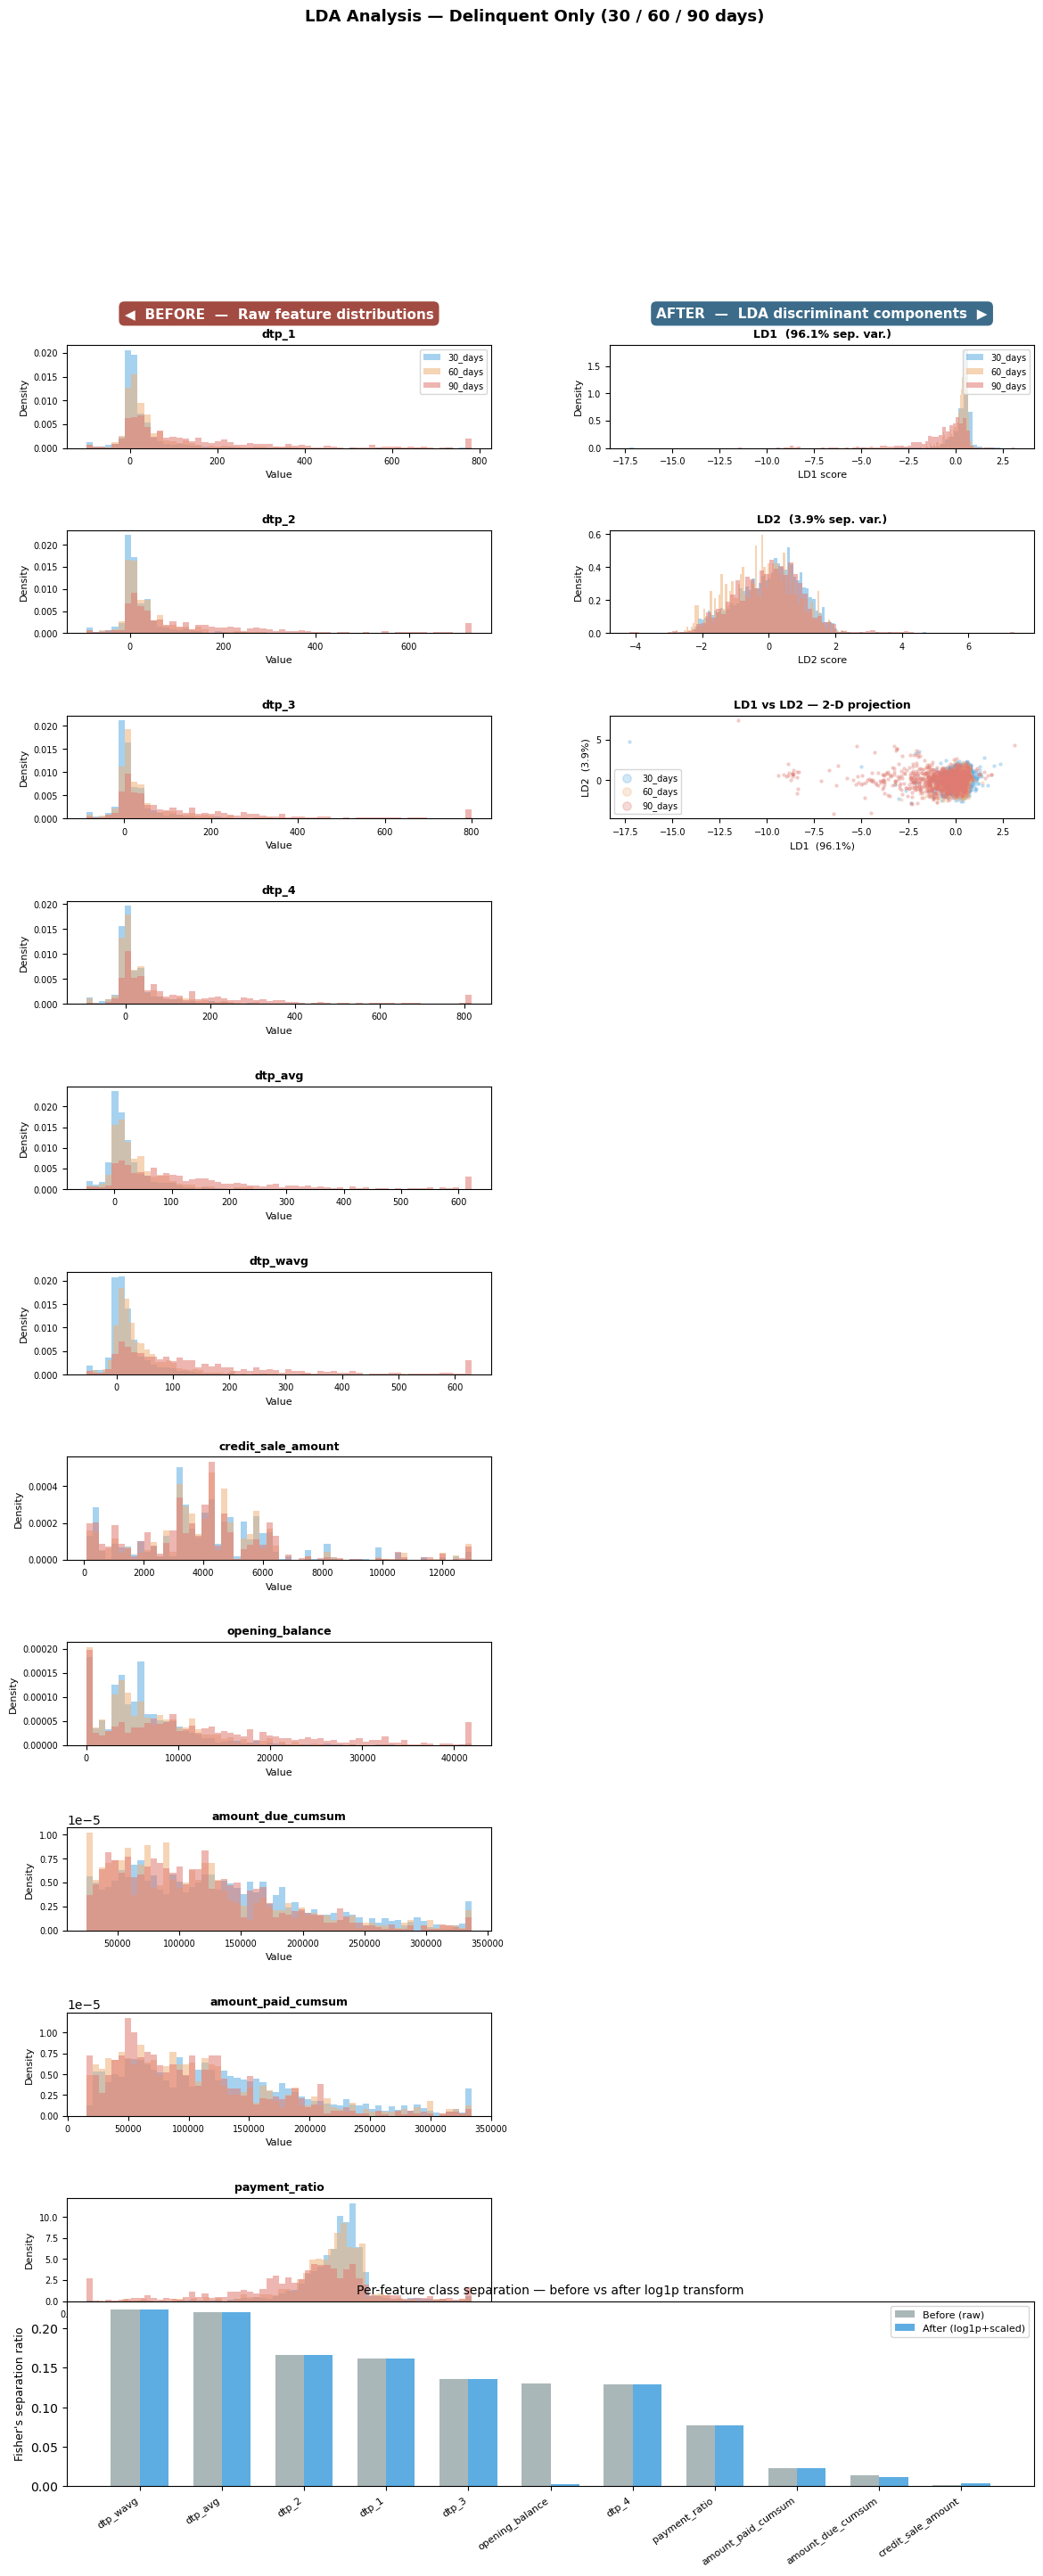

In [ ]:
from src.modules.exploratory_data_analysis.linear_discriminant_analysis import LDAAnalysis

lda_delinquent = LDAAnalysis(
    df_credit_sales,
    bracket_order = ['30_days', '60_days', '90_days'],
    output_path   = 'data/eda_results/lda_delinquent.png',
    title         = 'LDA Analysis — Delinquent Only (30 / 60 / 90 days)',
)
pipe, X_lda, evr, sep_df = lda_delinquent.run()